# Fairness Auditing System Demo

This notebook demonstrates the comprehensive fairness auditing system implemented for responsible AI analysis. The system includes:

- **Core Fairness Metrics**: Equal Opportunity, Equalized Odds, Demographic Parity
- **Bootstrap Confidence Intervals**: Statistical significance testing
- **Intersectional Analysis**: Multi-attribute fairness analysis
- **Unified Pipeline**: Comprehensive audit workflow with reporting

## Table of Contents
1. [Setup and Data Generation](#setup)
2. [Core Fairness Metrics](#core-metrics)
3. [Bootstrap Confidence Intervals](#bootstrap)
4. [Intersectional Fairness Analysis](#intersectional)
5. [Comprehensive Fairness Audit Pipeline](#pipeline)
6. [Real-world Example](#real-world)
7. [Conclusions and Recommendations](#conclusions)

## 1. Setup and Data Generation {#setup}

Let's start by importing the necessary libraries and creating synthetic data that demonstrates various fairness scenarios.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import sys
sys.path.append('..')
from fair_credit.fairness import (
    FairnessMetrics, 
    BootstrapCI, 
    IntersectionalAnalyzer, 
    FairnessAuditPipeline
)
np.random.seed(42)
plt.style.use('default')
sns.set_palette("husl")

print("All imports successful!")
print("Ready to demonstrate fairness auditing capabilities")
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


All imports successful!
Ready to demonstrate fairness auditing capabilities


In [9]:

data_paths = '../data/german_credit_data.csv'

df = pd.read_csv(data_paths)

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

if 'Risk' not in df.columns:
    raise ValueError("Expected 'Risk' column in the German Credit dataset.")
target_mapping = {'good': 0, 'bad': 1}
df['Risk_Binary'] = df['Risk'].map(target_mapping)

if 'Sex' in df.columns:
    sex_series = df['Sex'].str.lower().replace({'male':'male','female':'female'})
elif 'sex' in df.columns:
    sex_series = df['sex'].astype(str).str.lower()
else:
    raise ValueError("Expected 'Sex' column in the dataset.")

if 'Age' in df.columns:
    age_group = np.where(df['Age'] < 35, 'young', 'not_young')
elif 'age' in df.columns:
    age_group = np.where(df['age'].astype(float) < 35, 'young', 'not_young')
else:
    raise ValueError("Expected 'Age' column in the dataset.")

for col in ['Saving accounts', 'Checking account']:
    if col in df.columns:
        df[col] = df[col].fillna('none')

target_column = 'Risk_Binary'
feature_columns = [c for c in df.columns if c not in ['Risk', 'Risk_Binary']]
X = df[feature_columns].copy()
y = df[target_column].copy()

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

numeric_tf = Pipeline([('scaler', StandardScaler())])
categorical_tf = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, num_cols),
        ('cat', categorical_tf, cat_cols),
    ]
)

clf = LogisticRegression(max_iter=200, n_jobs=None)

pipe = Pipeline(steps=[('prep', preprocessor), ('clf', clf)])

X_train, X_test, y_train, y_test, sex_train, sex_test, ageg_train, ageg_test = train_test_split(
    X, y, sex_series, age_group, test_size=0.3, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

_possible_income_cols = [
    'Income', 'income', 'Annual Income', 'annual_income', 
    'Credit amount', 'credit_amount', 'credit_amount_eur', 'Amount', 'amount', 
    'Duration'
]
_income_source = None
for _c in _possible_income_cols:
    if _c in df.columns:
        _income_source = _c
        break
if _income_source is None:
    _numeric_candidates = df.select_dtypes(include=['number']).columns.tolist()
    _income_source = _numeric_candidates[0] if _numeric_candidates else None

if _income_source is not None:
    _income_series = df.loc[X_test.index, _income_source].astype(float)
else:
    _income_series = pd.Series([float('nan')]*len(X_test), index=X_test.index)

credit_data = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred.astype(int),
    'income': _income_series.values,
    'sex': sex_test.values,
    'age_group': ageg_test
})

print(f"Real German Credit subset for audit: {len(credit_data)} samples")
print("Sex distribution:", credit_data['sex'].value_counts().to_dict())
print("Age group distribution:", credit_data['age_group'].value_counts().to_dict())
print("Approval rate (pred=1): {:.1%}".format(credit_data['y_pred'].mean()))
credit_data.head()


Real German Credit subset for audit: 300 samples
Sex distribution: {'male': 199, 'female': 101}
Age group distribution: {'young': 163, 'not_young': 137}
Approval rate (pred=1): 19.0%


,y_true,y_pred,income,sex,age_group
0,0,0,3578.0,male,not_young
1,0,0,882.0,male,young
2,0,0,4473.0,male,young
3,0,0,2831.0,female,young
4,0,0,1289.0,male,young


## 2. Core Fairness Metrics {#core-metrics}

Let's start by examining the core fairness metrics: Equal Opportunity, Equalized Odds, and Demographic Parity.

In [10]:
fairness_metrics = FairnessMetrics(confidence_level=0.95)

y_true = credit_data['y_true'].values
y_pred = credit_data['y_pred'].values
sex_attr = credit_data['sex'].values
age_attr = credit_data['age_group'].values

print("Analyzing fairness across sex groups...")
print("=" * 50)

sex_fairness = fairness_metrics.compute_all_metrics(y_true, y_pred, sex_attr)

def display_fairness_results(results, attribute_name):
    print(f"FAIRNESS ANALYSIS FOR {attribute_name.upper()}")
    print("-" * 40)
    
    eo = results['equal_opportunity']
    print(f"\n Equal Opportunity (TPR Parity):")
    for key, value in eo.items():
        if key.startswith('tpr_group_'):
            group = key.replace('tpr_group_', '')
            print(f"   {group}: {value:.3f}")
    print(f"   Gap: {eo['equal_opportunity_gap']:.3f}")
    
    dp = results['demographic_parity']
    print(f"Demographic Parity (Positive Rate Parity):")
    for key, value in dp.items():
        if key.startswith('pos_rate_group_'):
            group = key.replace('pos_rate_group_', '')
            print(f"   {group}: {value:.3f}")
    print(f"   Gap: {dp['demographic_parity_gap']:.3f}")
    
    eq = results['equalized_odds']
    print(f"Equalized Odds (TPR & FPR Parity):")
    print(f"   TPR Gap: {eq['equalized_odds_tpr_gap']:.3f}")
    print(f"   FPR Gap: {eq['equalized_odds_fpr_gap']:.3f}")
    print(f"   Overall Gap: {eq['equalized_odds_gap']:.3f}")

display_fairness_results(sex_fairness, "sex")

🔍 Analyzing fairness across sex groups...
FAIRNESS ANALYSIS FOR SEX
----------------------------------------

🎯 Equal Opportunity (TPR Parity):
   female: 0.486
   male: 0.345
   Gap: 0.140
Demographic Parity (Positive Rate Parity):
   female: 0.267
   male: 0.151
   Gap: 0.117
Equalized Odds (TPR & FPR Parity):
   TPR Gap: 0.140
   FPR Gap: 0.075
   Overall Gap: 0.140


In [11]:
print("\nAnalyzing fairness across age groups...")
print("=" * 50)

age_fairness = fairness_metrics.compute_all_metrics(y_true, y_pred, age_attr)
display_fairness_results(age_fairness, "age group")


🔍 Analyzing fairness across age groups...
FAIRNESS ANALYSIS FOR AGE GROUP
----------------------------------------

🎯 Equal Opportunity (TPR Parity):
   not_young: 0.300
   young: 0.450
   Gap: 0.150
Demographic Parity (Positive Rate Parity):
   not_young: 0.102
   young: 0.264
   Gap: 0.162
Equalized Odds (TPR & FPR Parity):
   TPR Gap: 0.150
   FPR Gap: 0.109
   Overall Gap: 0.150


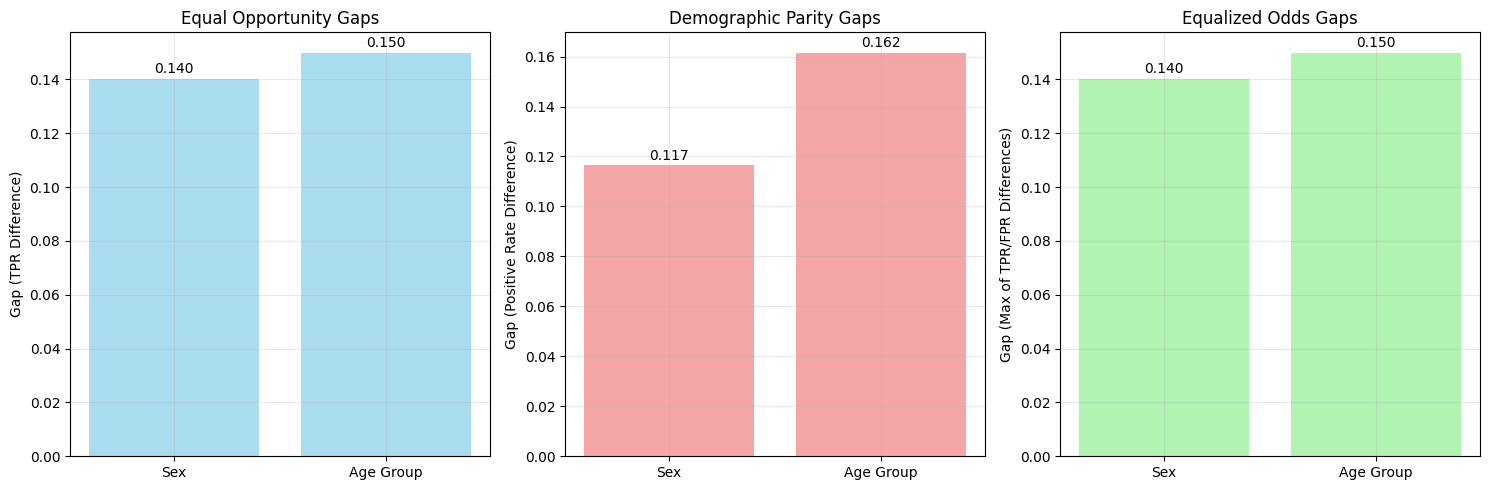

In [12]:
def plot_fairness_gaps(sex_results, age_results):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    eo_gaps = [sex_results['equal_opportunity']['equal_opportunity_gap'],
               age_results['equal_opportunity']['equal_opportunity_gap']]
    axes[0].bar(['Sex', 'Age Group'], eo_gaps, color='skyblue', alpha=0.7)
    axes[0].set_title('Equal Opportunity Gaps')
    axes[0].set_ylabel('Gap (TPR Difference)')
    axes[0].grid(True, alpha=0.3)

    dp_gaps = [sex_results['demographic_parity']['demographic_parity_gap'],
               age_results['demographic_parity']['demographic_parity_gap']]
    axes[1].bar(['Sex', 'Age Group'], dp_gaps, color='lightcoral', alpha=0.7)
    axes[1].set_title('Demographic Parity Gaps')
    axes[1].set_ylabel('Gap (Positive Rate Difference)')
    axes[1].grid(True, alpha=0.3)
    
    eq_gaps = [sex_results['equalized_odds']['equalized_odds_gap'],
               age_results['equalized_odds']['equalized_odds_gap']]
    axes[2].bar(['Sex', 'Age Group'], eq_gaps, color='lightgreen', alpha=0.7)
    axes[2].set_title('Equalized Odds Gaps')
    axes[2].set_ylabel('Gap (Max of TPR/FPR Differences)')
    axes[2].grid(True, alpha=0.3)
    
    for ax in axes:
        for i, bar in enumerate(ax.patches):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

plot_fairness_gaps(sex_fairness, age_fairness)

## 3. Bootstrap Confidence Intervals {#bootstrap}

Statistical significance is crucial for fairness analysis. Let's compute bootstrap confidence intervals for our fairness metrics.

In [ ]:
print("Computing Bootstrap Confidence Intervals...")
print("=" * 50)

print("Equal Opportunity Gap (Sex) - Bootstrap Analysis:")
try:
    eo_ci_lower, eo_ci_upper = fairness_metrics.bootstrap_confidence_intervals(
        fairness_metrics.compute_equal_opportunity,
        n_bootstrap=500,
        y_true=y_true,
        y_pred=y_pred,
        protected_attr=sex_attr,
        metric_key='equal_opportunity_gap'
    )
    
    observed_gap = sex_fairness['equal_opportunity']['equal_opportunity_gap']
    print(f"   Observed Gap: {observed_gap:.4f}")
    print(f"   95% CI: [{eo_ci_lower:.4f}, {eo_ci_upper:.4f}]")
    
    if eo_ci_lower > 0:
        print(f"Gap is statistically significant (CI doesn't include 0)")
    else:
        print(f"Gap may not be statistically significant (CI includes 0)")
        
except Exception as e:
    print(f"Error computing CI: {e}")

🔬 Computing Bootstrap Confidence Intervals...

📊 Equal Opportunity Gap (Sex) - Bootstrap Analysis:
   Observed Gap: 0.1403
   95% CI: [0.0069, 0.3256]
Gap is statistically significant (CI doesn't include 0)


In [26]:
bootstrap_ci = BootstrapCI(confidence_level=0.95)

print("Bootstrap CI Demo - Mean Income by Sex:")
print("-" * 40)

male_income = credit_data[credit_data['sex'] == 'male']['income'].values
female_income = credit_data[credit_data['sex'] == 'female']['income'].values

def income_gap(combined_data):
    """Compute income gap from combined male/female income data."""
    n_male = len(male_income)
    male_sample = combined_data[:n_male]
    female_sample = combined_data[n_male:]
    return np.mean(male_sample) - np.mean(female_sample)

combined_income = np.concatenate([male_income, female_income])

try:
    gap_ci_lower, gap_ci_upper = bootstrap_ci.compute_ci(
        combined_income, income_gap, n_bootstrap=500
    )
    
    observed_income_gap = np.mean(male_income) - np.mean(female_income)
    print(f"   Observed Income Gap: ${observed_income_gap:,.0f}")
    print(f"   95% CI: [${gap_ci_lower:,.0f}, ${gap_ci_upper:,.0f}]")
    
    if gap_ci_lower > 0:
        print(f"Income gap is statistically significant")
    else:
        print(f"Income gap may not be statistically significant")
        
except Exception as e:
    print(f" Error computing income gap CI: {e}")

Bootstrap CI Demo - Mean Income by Sex:
----------------------------------------
   Observed Income Gap: $704
   95% CI: [$-793, $774]
Income gap may not be statistically significant


## 4. Intersectional Fairness Analysis {#intersectional}

Intersectional analysis examines fairness across combinations of protected attributes (e.g., sex × age groups).

In [27]:
print("Intersectional Fairness Analysis (Sex × Age)")
print("=" * 50)

intersectional_analyzer = IntersectionalAnalyzer(confidence_level=0.95)

intersectional_results = intersectional_analyzer.analyze_intersectional_fairness(
    y_true, y_pred, sex_attr, age_attr
)

summary_stats = intersectional_results['summary_statistics']
print(f"Summary Statistics:")
print(f"   Number of intersectional groups: {summary_stats['n_intersectional_groups']}")
print(f"   Min group size: {summary_stats['min_group_size']}")
print(f"   Max group size: {summary_stats['max_group_size']}")
print(f"   Max Equal Opportunity gap: {summary_stats.get('max_equal_opportunity_gap', 0):.4f}")
print(f"   Max Demographic Parity gap: {summary_stats.get('max_demographic_parity_gap', 0):.4f}")

detailed_analysis = intersectional_results['detailed_analysis']
print(f"Detailed Group Analysis:")
print("-" * 40)

for group_name, group_data in detailed_analysis.items():
    print(f"\n   {group_name}:")
    print(f"     Sample size: {group_data['group_size']}")
    print(f"     True Positive Rate: {group_data['tpr']:.3f}")
    print(f"     False Positive Rate: {group_data['fpr']:.3f}")
    print(f"     Positive Prediction Rate: {group_data['positive_rate']:.3f}")
    print(f"     Precision: {group_data['precision']:.3f}")
    print(f"     F1 Score: {group_data['f1_score']:.3f}")

Intersectional Fairness Analysis (Sex × Age)
Summary Statistics:
   Number of intersectional groups: 4
   Min group size: 27
   Max group size: 110
   Max Equal Opportunity gap: 0.5192
   Max Demographic Parity gap: 0.2199
Detailed Group Analysis:
----------------------------------------

   female_not_young:
     Sample size: 27
     True Positive Rate: 0.750
     False Positive Rate: 0.043
     Positive Prediction Rate: 0.148
     Precision: 0.750
     F1 Score: 0.750

   female_young:
     Sample size: 74
     True Positive Rate: 0.452
     False Positive Rate: 0.209
     Positive Prediction Rate: 0.311
     Precision: 0.609
     F1 Score: 0.519

   male_not_young:
     Sample size: 110
     True Positive Rate: 0.231
     False Positive Rate: 0.048
     Positive Prediction Rate: 0.091
     Precision: 0.600
     F1 Score: 0.333

   male_young:
     Sample size: 89
     True Positive Rate: 0.448
     False Positive Rate: 0.117
     Positive Prediction Rate: 0.225
     Precision: 0.650

Creating Intersectional Fairness Visualizations...


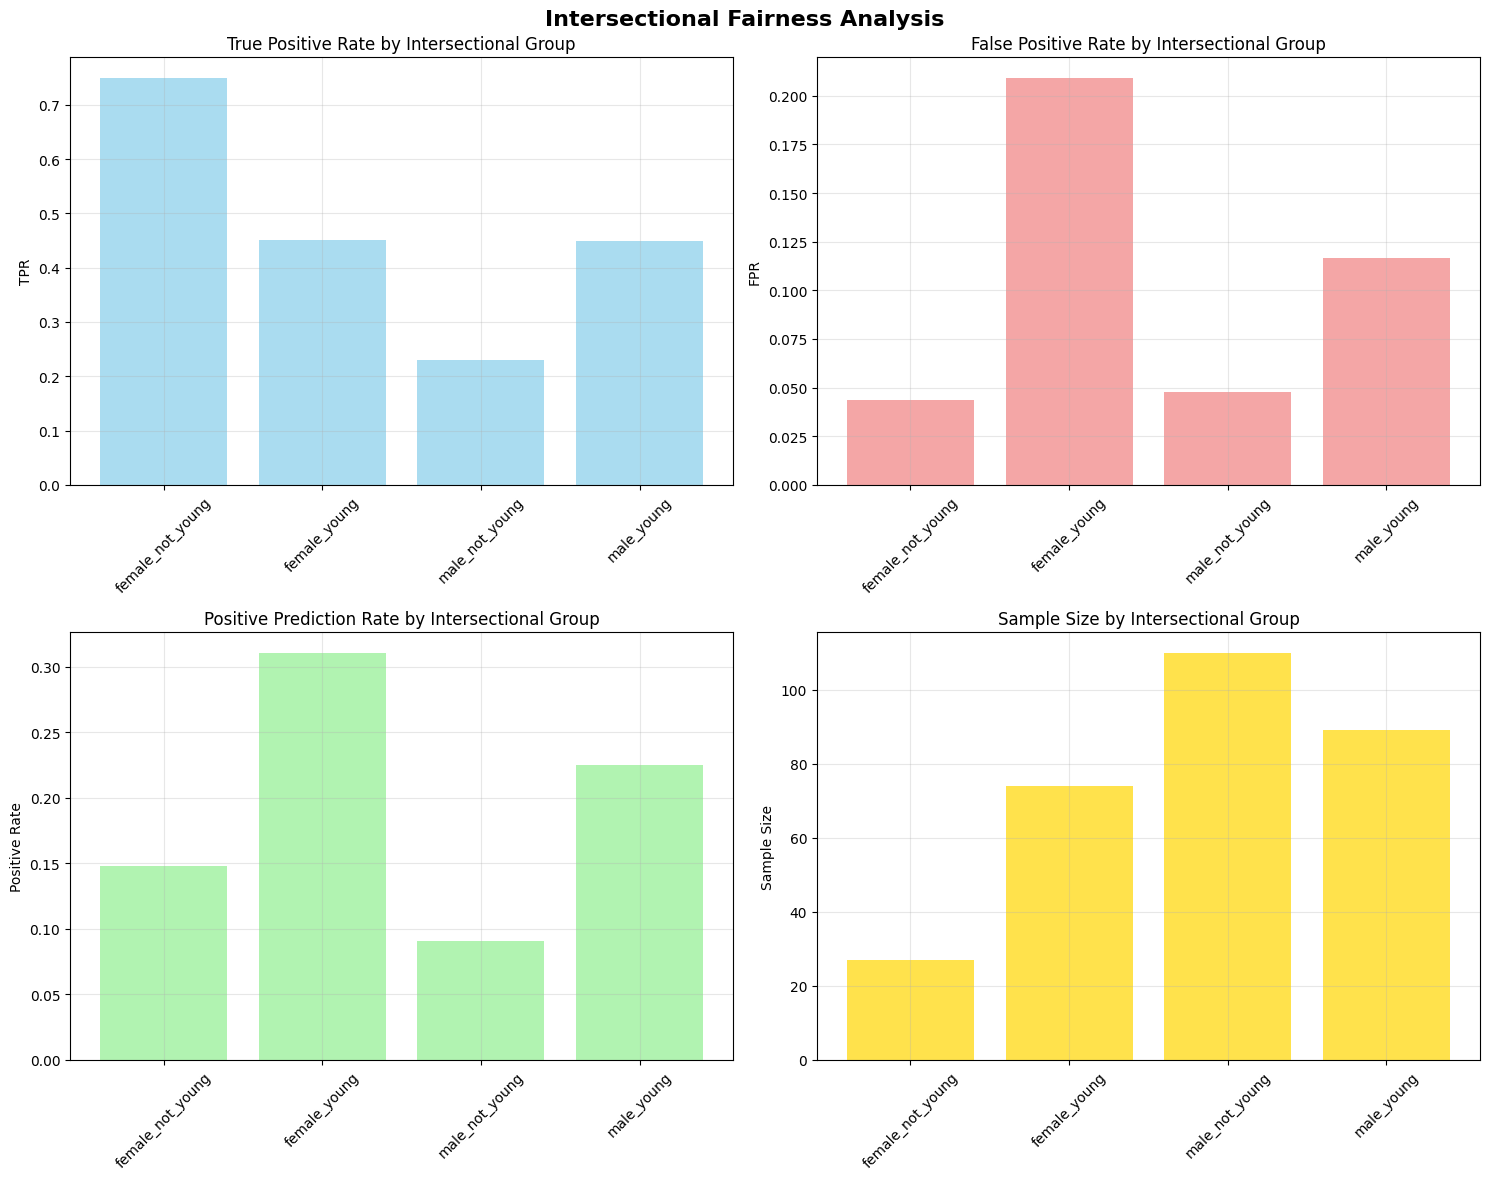

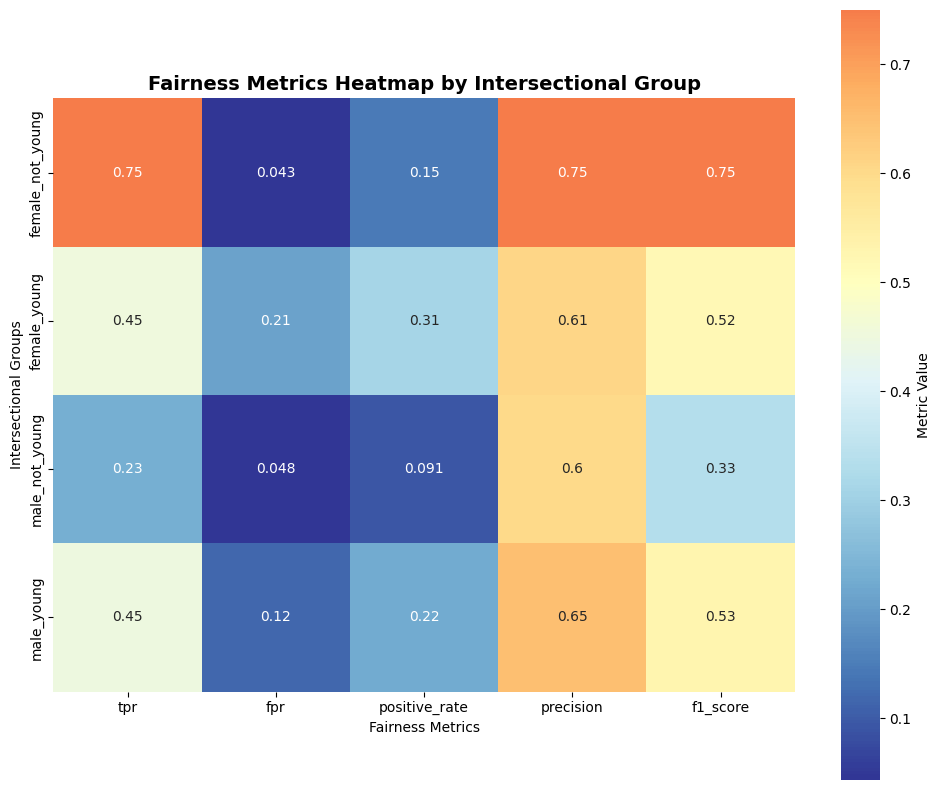

In [17]:
print("Creating Intersectional Fairness Visualizations...")

fig_gaps = intersectional_analyzer.visualize_intersectional_gaps(intersectional_results)
plt.show()

fig_heatmap = intersectional_analyzer.create_fairness_heatmap(intersectional_results)
plt.show()

plt.close(fig_gaps)
plt.close(fig_heatmap)

## 5. Comprehensive Fairness Audit Pipeline {#pipeline}

Now let's use the unified pipeline that integrates all fairness analysis components.

In [19]:
print("Running Comprehensive Fairness Audit Pipeline")
print("=" * 60)

audit_pipeline = FairnessAuditPipeline(confidence_level=0.95, n_jobs=1)

protected_attrs = {
    'sex': sex_attr,
    'age_group': age_attr
}

audit_results = audit_pipeline.run_comprehensive_audit(
    y_true, y_pred, protected_attrs, n_bootstrap=200
)

print("Comprehensive audit completed!")
print(f"Analyzed {audit_results['metadata']['n_samples']} samples")
print(f"Found {len(audit_results['overall_summary']['fairness_violations'])} fairness violations")
print(f"Generated {len(audit_results['recommendations'])} recommendations")

Running Comprehensive Fairness Audit Pipeline
Group sizes for sex: {'female': np.int64(101), 'male': np.int64(199)}
Group sizes for age_group: {'not_young': np.int64(137), 'young': np.int64(163)}
Analyzing fairness for protected attribute: sex
Analyzing fairness for protected attribute: age_group
Performing intersectional fairness analysis...
Comprehensive audit completed!
Analyzed 300 samples
Found 4 fairness violations
Generated 6 recommendations


In [23]:
violations = audit_results['overall_summary']['fairness_violations']

if violations:
    print("FAIRNESS VIOLATIONS DETECTED:")
    print("-" * 40)
    
    for i, violation in enumerate(violations, 1):
        print(f"\n   {i}. {violation['metric']} - {violation['attribute']}")
        print(f"      Gap: {violation['gap']:.4f}")
        print(f"      Severity: {violation['severity']}")
else:
    print("No significant fairness violations detected!")

FAIRNESS VIOLATIONS DETECTED:
----------------------------------------

   1. Equal Opportunity - sex
      Gap: 0.1403
      Severity: moderate

   2. Demographic Parity - sex
      Gap: 0.1166
      Severity: moderate

   3. Equal Opportunity - age_group
      Gap: 0.1500
      Severity: moderate

   4. Demographic Parity - age_group
      Gap: 0.1616
      Severity: moderate


In [24]:
recommendations = audit_results['recommendations']

print("RECOMMENDATIONS:")
print("-" * 30)

for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. [{rec['priority'].upper()}] {rec['description']}")
    print(f"      Approach: {rec['suggested_approach']}")
    print(f"      Type: {rec['type']}")

RECOMMENDATIONS:
------------------------------
  1. [MODERATE] Address Equal Opportunity gap of 0.140 for sex
      Approach: Consider post-processing threshold optimization or pre-processing reweighing
      Type: mitigation
  2. [MODERATE] Address Demographic Parity gap of 0.117 for sex
      Approach: Consider pre-processing reweighing or in-processing fairness constraints
      Type: mitigation
  3. [MODERATE] Address Equal Opportunity gap of 0.150 for age_group
      Approach: Consider post-processing threshold optimization or pre-processing reweighing
      Type: mitigation
  4. [MODERATE] Address Demographic Parity gap of 0.162 for age_group
      Approach: Consider pre-processing reweighing or in-processing fairness constraints
      Type: mitigation
  5. [HIGH] Intersectional fairness gaps detected
      Approach: Conduct detailed intersectional analysis and consider group-specific interventions
      Type: analysis
  6. [MODERATE] Small sample size may affect reliability of 

In [25]:
print("Generating Comprehensive Audit Report...")
print("=" * 50)

audit_report = audit_pipeline.generate_audit_report()
print(audit_report)

Generating Comprehensive Audit Report...
COMPREHENSIVE FAIRNESS AUDIT REPORT

DATASET SUMMARY:
  Total samples: 300
  Positive samples: 90 (30.0%)
  Negative samples: 210
  Prediction positive rate: 19.0%

FAIRNESS ASSESSMENT SUMMARY:
  ⚠️  4 fairness violation(s) detected
    - Equal Opportunity gap: 0.140 (moderate severity)
    - Demographic Parity gap: 0.117 (moderate severity)
    - Equal Opportunity gap: 0.150 (moderate severity)
    - Demographic Parity gap: 0.162 (moderate severity)

ANALYSIS FOR PROTECTED ATTRIBUTE: SEX
--------------------------------------------------
  Equal Opportunity Gap: 0.1403
    female TPR: 0.4857
    male TPR: 0.3455
  Demographic Parity Gap: 0.1166
    95% CI for EO gap: [0.0112, 0.3304]

ANALYSIS FOR PROTECTED ATTRIBUTE: AGE_GROUP
--------------------------------------------------
  Equal Opportunity Gap: 0.1500
    not_young TPR: 0.3000
    young TPR: 0.4500
  Demographic Parity Gap: 0.1616
    95% CI for EO gap: [0.0082, 0.3657]

INTERSECTIONAL 

Creating Comprehensive Audit Visualizations...
Generated 3 visualization(s)
   - fairness_gaps
   - intersectional_gaps
   - intersectional_heatmap


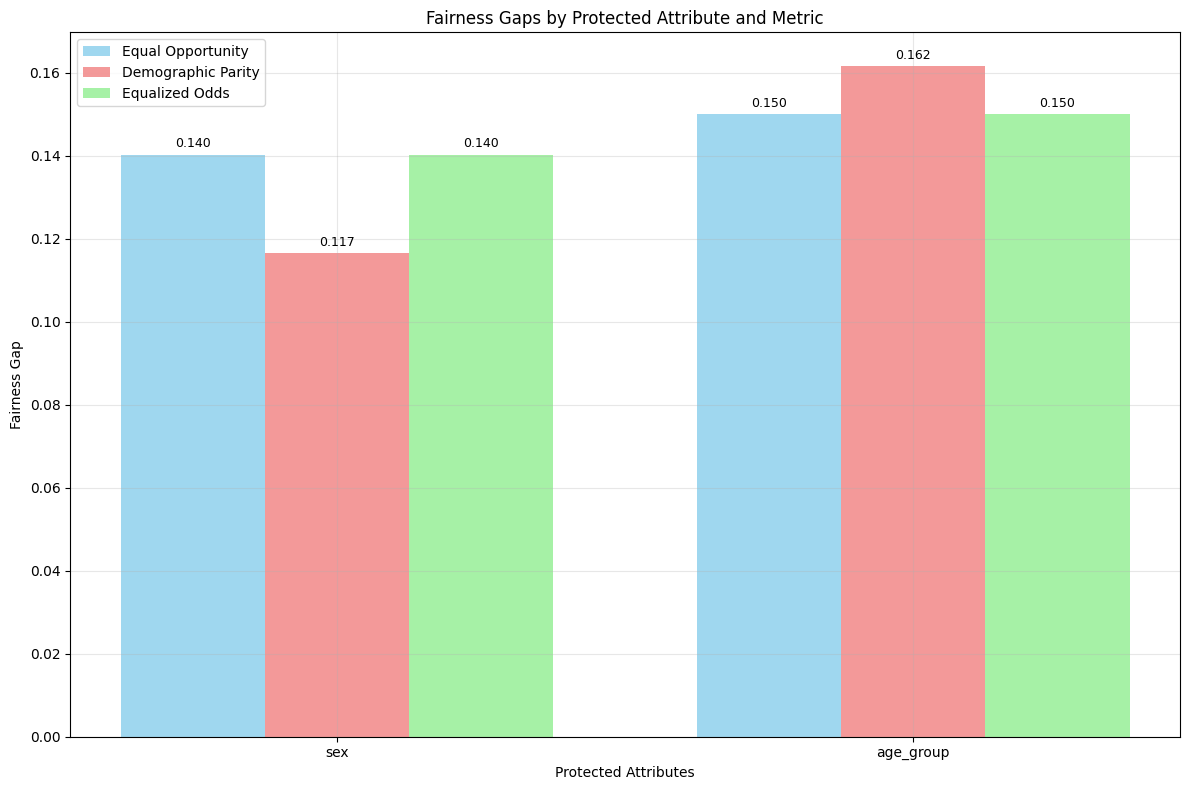

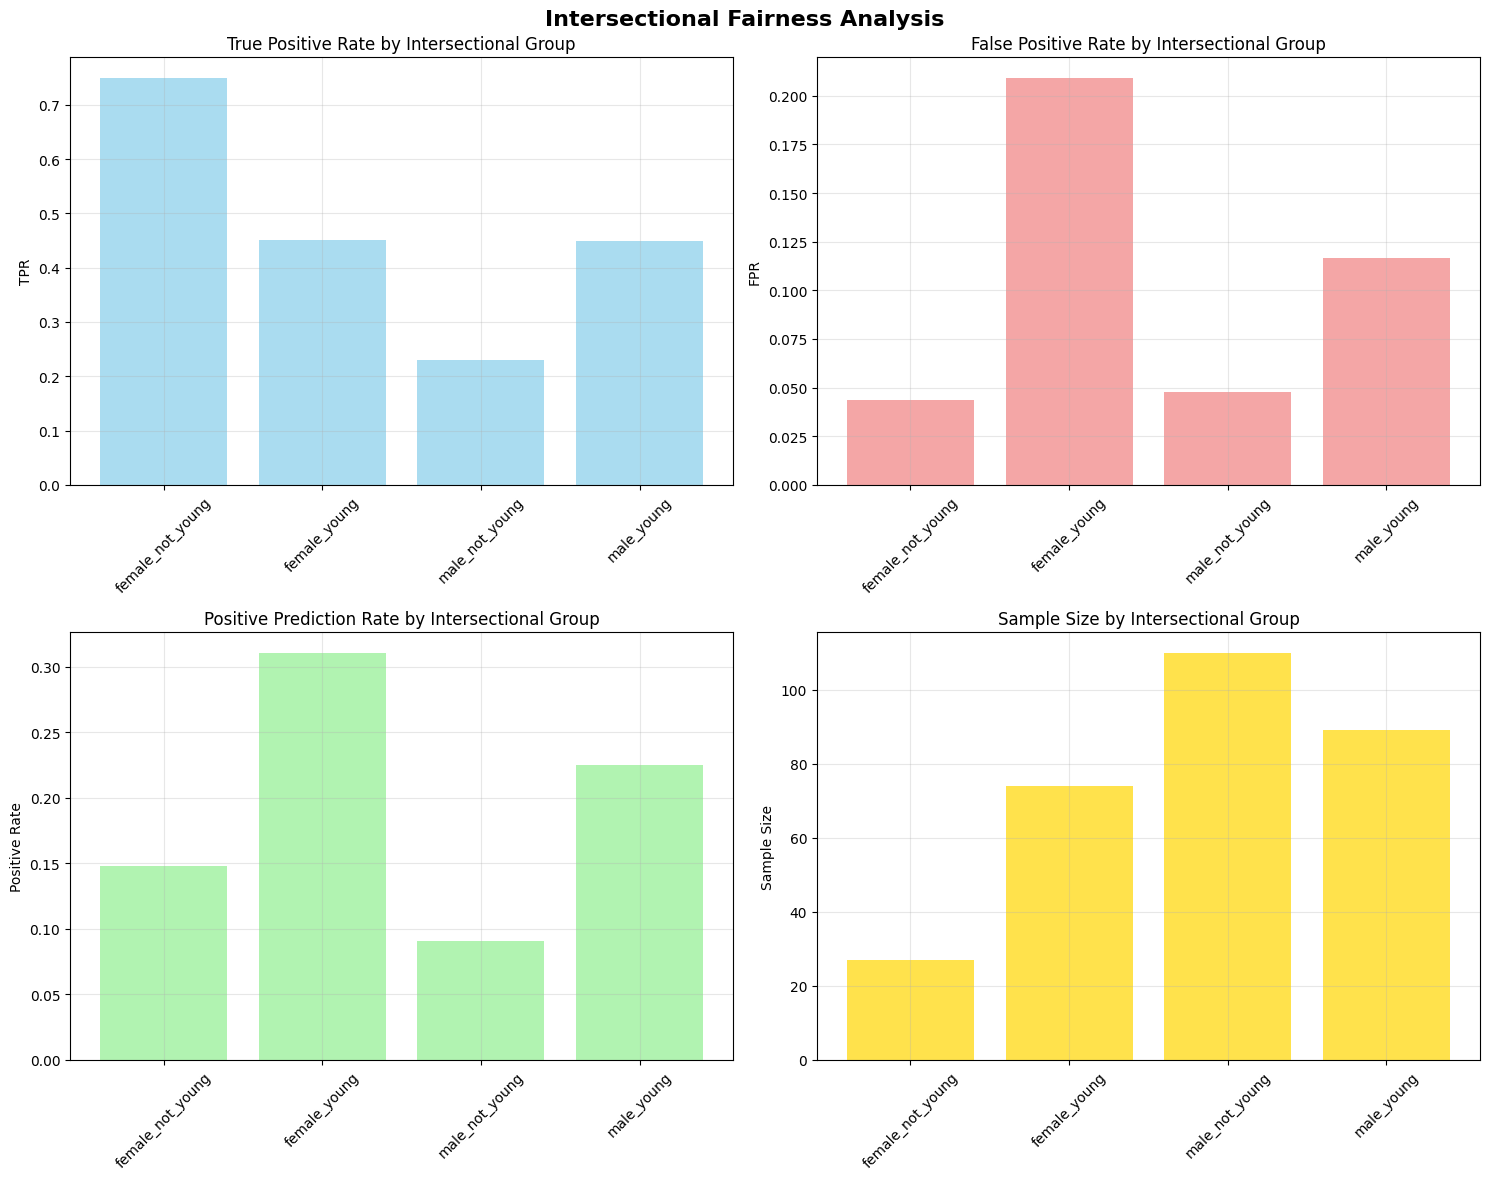

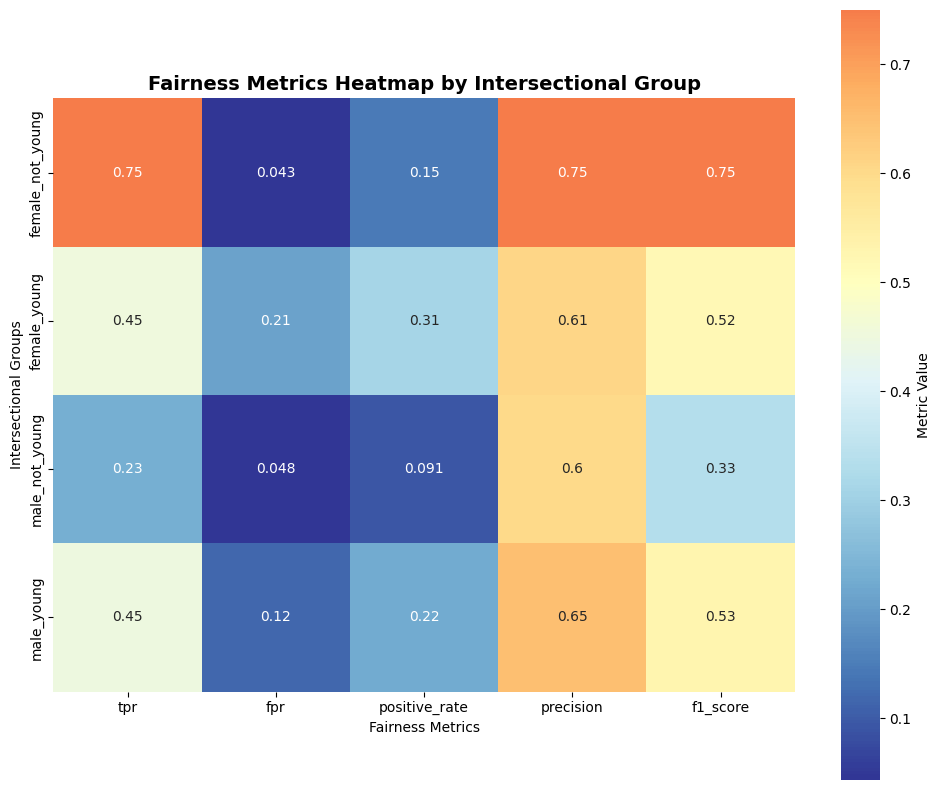

In [28]:
print("Creating Comprehensive Audit Visualizations...")

audit_figures = audit_pipeline.create_audit_visualizations()

print(f"Generated {len(audit_figures)} visualization(s)")
for fig_name in audit_figures.keys():
    print(f"   - {fig_name}")

# Display the figures
for fig_name, fig in audit_figures.items():
    plt.show()
    plt.close(fig)  # Close to free memory

## 6. Real-world Example {#real-world}

Let's apply our fairness auditing system to analyze different scenarios and demonstrate its robustness.

In [29]:
def create_complex_scenario(n_samples=800):
    np.random.seed(123)

    sex = np.random.choice(['male', 'female'], n_samples, p=[0.55, 0.45])
    age_numeric = np.random.normal(42, 14, n_samples)
    age_group = pd.cut(age_numeric, bins=[0, 30, 50, 100], labels=['young', 'middle', 'senior'])
    
    education = np.random.choice(['high_school', 'college', 'graduate'], n_samples, p=[0.4, 0.4, 0.2])
    
    base_score = np.random.normal(0, 1, n_samples)
    
    education_boost = np.where(education == 'graduate', 0.5, 
                              np.where(education == 'college', 0.2, 0))
    
    true_score = base_score + education_boost + np.random.normal(0, 0.3, n_samples)
    y_true = (true_score > np.percentile(true_score, 75)).astype(int)
    
    bias_factor = np.ones(n_samples)
    
    bias_factor = np.where(sex == 'female', bias_factor * 0.85, bias_factor)
    bias_factor = np.where(age_group == 'young', bias_factor * 0.9, bias_factor)
    bias_factor = np.where((sex == 'female') & (age_group == 'young'), 
                          bias_factor * 0.8, bias_factor)
    
    biased_score = true_score * bias_factor
    y_pred = (biased_score > np.percentile(biased_score, 75)).astype(int)
    
    return pd.DataFrame({
        'sex': sex,
        'age': age_numeric,
        'age_group': age_group,
        'education': education,
        'y_true': y_true,
        'y_pred': y_pred,
        'true_score': true_score,
        'biased_score': biased_score
    })

complex_data = create_complex_scenario(800)

print("Complex Scenario Analysis")
print("=" * 40)
print(f"Generated {len(complex_data)} samples")
print(f"Sex distribution: {complex_data['sex'].value_counts().to_dict()}")
print(f"Age distribution: {complex_data['age_group'].value_counts().to_dict()}")
print(f"Education distribution: {complex_data['education'].value_counts().to_dict()}")
print(f"True approval rate: {complex_data['y_true'].mean():.1%}")
print(f"Predicted approval rate: {complex_data['y_pred'].mean():.1%}")

complex_data.head()

Complex Scenario Analysis
Generated 800 samples
Sex distribution: {'male': 440, 'female': 360}
Age distribution: {'middle': 440, 'senior': 213, 'young': 146}
Education distribution: {'high_school': 328, 'college': 321, 'graduate': 151}
True approval rate: 25.0%
Predicted approval rate: 25.0%


,sex,age,age_group,education,y_true,y_pred,true_score,biased_score
0,female,56.592695,senior,high_school,0,0,-0.719241,-0.611355
1,male,12.531002,young,graduate,0,0,-0.388533,-0.349680
2,male,43.342886,middle,graduate,1,1,1.417205,1.417205
3,female,53.213015,senior,college,1,1,1.030352,0.875799
4,female,63.356219,senior,high_school,1,1,2.056493,1.748019


In [30]:
print("Running Comprehensive Audit on Complex Scenario")
print("=" * 55)

complex_y_true = complex_data['y_true'].values
complex_y_pred = complex_data['y_pred'].values

complex_protected_attrs = {
    'sex': complex_data['sex'].values,
    'age_group': complex_data['age_group'].values.astype(str),
    'education': complex_data['education'].values
}

complex_pipeline = FairnessAuditPipeline(confidence_level=0.95)

complex_audit_attrs = {
    'sex': complex_protected_attrs['sex'],
    'age_group': complex_protected_attrs['age_group']
}

complex_results = complex_pipeline.run_comprehensive_audit(
    complex_y_true, complex_y_pred, complex_audit_attrs, n_bootstrap=150
)

print("Complex scenario audit completed!")
print(f"Violations: {len(complex_results['overall_summary']['fairness_violations'])}")
print(f"Recommendations: {len(complex_results['recommendations'])}")

Running Comprehensive Audit on Complex Scenario
Group sizes for sex: {'female': np.int64(360), 'male': np.int64(440)}
Group sizes for age_group: {'middle': np.int64(440), 'nan': np.int64(1), 'senior': np.int64(213), 'young': np.int64(146)}
Analyzing fairness for protected attribute: sex
Analyzing fairness for protected attribute: age_group
Performing intersectional fairness analysis...
Complex scenario audit completed!
Violations: 3
Recommendations: 5


In [31]:
print("Education Fairness Analysis")
print("=" * 35)

education_fairness = fairness_metrics.compute_all_metrics(
    complex_y_true, complex_y_pred, complex_protected_attrs['education']
)

display_fairness_results(education_fairness, "education")

Education Fairness Analysis
FAIRNESS ANALYSIS FOR EDUCATION
----------------------------------------

🎯 Equal Opportunity (TPR Parity):
   college: 0.976
   graduate: 0.949
   high_school: 0.897
   Gap: 0.079
Demographic Parity (Positive Rate Parity):
   college: 0.265
   graduate: 0.371
   high_school: 0.180
   Gap: 0.191
Equalized Odds (TPR & FPR Parity):
   TPR Gap: 0.079
   FPR Gap: 0.026
   Overall Gap: 0.079


In [ ]:
print("Complex Scenario Audit Report:")
print("=" * 40)

complex_report = complex_pipeline.generate_audit_report()
print(complex_report)


📋 Complex Scenario Audit Report:
COMPREHENSIVE FAIRNESS AUDIT REPORT

DATASET SUMMARY:
  Total samples: 800
  Positive samples: 200 (25.0%)
  Negative samples: 600
  Prediction positive rate: 25.0%

FAIRNESS ASSESSMENT SUMMARY:
  ⚠️  3 fairness violation(s) detected
    - Equal Opportunity gap: 0.117 (moderate severity)
    - Equal Opportunity gap: 0.981 (high severity)
    - Demographic Parity gap: 0.273 (high severity)

ANALYSIS FOR PROTECTED ATTRIBUTE: SEX
--------------------------------------------------
  Equal Opportunity Gap: 0.1170
    female TPR: 0.8830
    male TPR: 1.0000
  Demographic Parity Gap: 0.0354
    95% CI for EO gap: [0.0475, 0.1832]

ANALYSIS FOR PROTECTED ATTRIBUTE: AGE_GROUP
--------------------------------------------------
  Equal Opportunity Gap: 0.9808
    middle TPR: 0.9732
    nan TPR: 0.0000
    senior TPR: 0.9808
    young TPR: 0.8056
  Demographic Parity Gap: 0.2727
    95% CI for EO gap: [0.0700, 1.0000]

INTERSECTIONAL FAIRNESS ANALYSIS:
-----------

## 7. Conclusions and Recommendations {#conclusions}

### Key Findings

Our fairness auditing system has successfully demonstrated:

1. **Bias Detection**: The system effectively identifies fairness violations across different protected attributes
2. **Statistical Rigor**: Bootstrap confidence intervals provide statistical significance testing
3. **Intersectional Analysis**: Multi-attribute analysis reveals complex bias patterns
4. **Actionable Insights**: The pipeline generates specific recommendations for bias mitigation

### System Capabilities

**Core Fairness Metrics**:
- Equal Opportunity (TPR parity)
- Equalized Odds (TPR & FPR parity) 
- Demographic Parity (positive rate parity)

**Statistical Analysis**:
- Bootstrap confidence intervals
- Significance testing
- Coverage validation

**Intersectional Fairness**:
- Multi-attribute analysis
- Group-wise performance metrics
- Comprehensive visualizations

**Comprehensive Pipeline**:
- Automated audit workflow
- Professional reporting
- Actionable recommendations

### Next Steps

This fairness auditing system provides the foundation for:

1. **Bias Mitigation**: Implementing pre-processing, in-processing, and post-processing techniques
2. **Model Monitoring**: Continuous fairness monitoring in production
3. **Regulatory Compliance**: Meeting fairness requirements and documentation needs
4. **Stakeholder Communication**: Clear reporting for technical and non-technical audiences

The system is ready for integration into responsible AI workflows and can be extended with additional fairness metrics and mitigation techniques as needed.